In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers,models
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from sklearn.preprocessing import normalize

In [2]:
X = np.load("X.npy")
y_act = np.load("y_act.npy")

print ( "X shape:",X.shape)
print ( "y_act shape:",y_act.shape)


X shape: (3521, 300, 90)
y_act shape: (3521,)


In [3]:
#Train/test split

X_train,X_test,y_train,y_test = train_test_split(
    X,y_act,
    test_size=0.2,
    random_state=42,
    stratify=y_act
)

print("Train:",X_train.shape)
print("Test:",X_test.shape)

Train: (2816, 300, 90)
Test: (705, 300, 90)


In [4]:
#normalizasyon ekleyelim

mean = np.mean(X_train)
std = np.std(X_train)

X_train =(X_train - mean )/std
X_test =(X_test - mean )/std


In [5]:
model = models.Sequential([
    layers.Conv1D(64,5, padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),
    
    layers.Conv1D(128,3, padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),
    
    layers.Conv1D(256,3, padding='same',activation='relu'),
    layers.BatchNormalization(),
    
    #feature sıkıştırılıyor
    layers.GlobalAveragePooling1D(),
    
    #Dense(128) temsil öğreniyor
    layers.Dense(128,activation='relu'),
    #16 hareket sınıfı
    layers.Dense(16,activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss= 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    X_train,y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.3135 - loss: 2.1848 - val_accuracy: 0.2695 - val_loss: 2.2853
Epoch 2/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5409 - loss: 1.4396 - val_accuracy: 0.4911 - val_loss: 1.6129
Epoch 3/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6279 - loss: 1.1473 - val_accuracy: 0.6578 - val_loss: 1.1197
Epoch 4/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6967 - loss: 0.9049 - val_accuracy: 0.7660 - val_loss: 0.8250
Epoch 5/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.7464 - loss: 0.7990 - val_accuracy: 0.7110 - val_loss: 0.8247
Epoch 6/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.7638 - loss: 0.7068 - val_accuracy: 0.7021 - val_loss: 0.8401
Epoch 7/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.7824 - loss: 0.6618 - val_accuracy: 0.8174 - val_loss: 0.5420
Epoch 8/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8162 - loss: 0.5530 - val_accuracy: 0.8280 - v

In [7]:
test_loss ,test_acc = model.evaluate(X_test,y_test)
print("Test accuracy:",test_acc)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9163 - loss: 0.2567
Test accuracy: 0.916312038898468


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


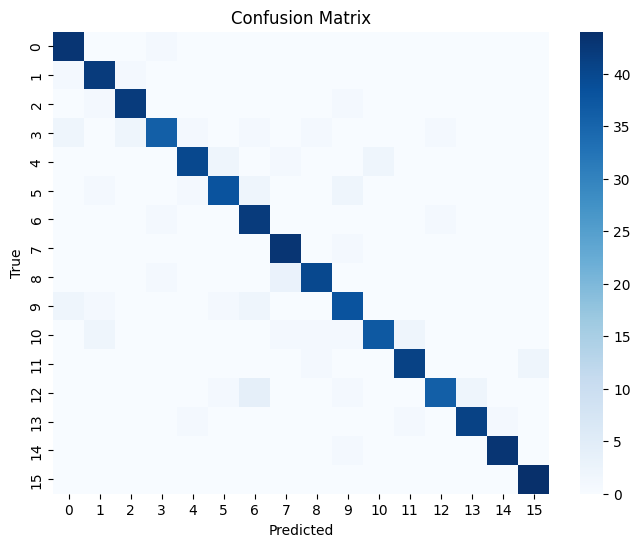

In [8]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred,axis=1)

cm = confusion_matrix(y_test,y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=False,cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [9]:
model.save("activity_model.h5")

In [10]:
#Softmaz'tan bir önceki katmanı al

embedding_model = Model(
   inputs=model.layers[0].input,
    outputs=model.layers[-2].output 
)
embedding_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 300, 90)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 300, 64)        │        28,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 300, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 150, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 150, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 75, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 75, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 75, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 186,816 (729.75 KB)

 Trainable params: 185,920 (726.25 KB)

 Non-trainable params: 896 (3.50 KB)

In [11]:
embeddings = embedding_model.predict(X)

print("Embedding shape:",embeddings.shape)

111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Embedding shape: (3521, 128)


In [12]:
embeddings = normalize(embeddings,axis=1)

#her embedding'in uzunluğunu 1 yapar.
#böylece cosine similarity=dor product olur

In [13]:
#notebooklar birbirinin belleğini paylaşamaz.HrEr notebook kendi RAM'inde çalışır.

X = np.load("X.npy")
y_user = np.load("y_user.npy")

In [14]:
# Aynı user'dan iki örnek
idx1 = np.where(y_user == 0)[0][0]
idx2 = np.where(y_user == 0)[0][1]

# Farklı user
idx3 = np.where(y_user == 1)[0][0]

sim_same = np.dot(embeddings[idx1], embeddings[idx2])
sim_diff = np.dot(embeddings[idx1], embeddings[idx3])

print("Same user similarity:", sim_same)
print("Different user similarity:", sim_diff)

Same user similarity: 0.95095015
Different user similarity: 0.8900098
